In [13]:
# ─── Cell 0: Extended setup ───────────────────────────────────────────────────
# Run this before any test cell. Adds metric-logging wrappers on top of your
# existing MPC-CBF initialisation block.

import numpy as np
import casadi
import time
from tqdm import tqdm
from collections import defaultdict
from plan_multi_bicycle import MPC_CBF_Bicycle, dm_to_array, animate


# ── Re-use your existing agent + trajectory setup ────────────────────────────
# (paste your original initialisation block here, ending with ref_state_list)

# ── Metric logger ─────────────────────────────────────────────────────────────
class MetricLogger:
    def __init__(self, n_agents, sep_min=1.0):
        self.n_agents   = n_agents
        self.sep_min    = sep_min
        self.solve_times   = defaultdict(list)   # {agent_id: [ms, ...]}
        self.separations   = []                  # min pairwise sep per timestep
        self.replan_events = []                  # (t, agent_id, trigger)
        self.infeasible    = []                  # (t, agent_id)
        self.path_lengths  = defaultdict(float)  # cumulative arc length

    def log_solve(self, j, elapsed_ms):
        self.solve_times[j].append(elapsed_ms)

    def log_separation(self, t, agent_states, obs):
        n = len(agent_states)
        min_d = np.inf
        for i in range(n):
            for k in range(i+1, n):
                d = np.sqrt((agent_states[i][0]-agent_states[k][0])**2 +
                            (agent_states[i][1]-agent_states[k][1])**2)
                min_d = min(min_d, d)
            for o in obs:
                d = np.sqrt((agent_states[i][0]-o[0])**2 +
                            (agent_states[i][1]-o[1])**2)
                min_d = min(min_d, d)    
        self.separations.append((t, min_d))

    def log_replan(self, t, j, trigger):
        self.replan_events.append((t, j, trigger))

    def log_infeasible(self, t, j):
        self.infeasible.append((t, j))

    def log_path(self, j, prev_state, curr_state):
        dx = curr_state[0] - prev_state[0]
        dy = curr_state[1] - prev_state[1]
        self.path_lengths[j] += np.sqrt(dx**2 + dy**2)

    def summary(self, T=0):
        sep_vals = [s for _, s in self.separations]
        print(f"\n{'═'*52}")
        print(f"  Solve latency (ms)")
        mean_latencies = []
        for j in range(self.n_agents):
            t_arr = np.array(self.solve_times[j])[T:]
            mean_latencies.append(t_arr.mean())
            print(f"    V{j+1}: mean={t_arr.mean():.1f}  "
                  f"p95={np.percentile(t_arr,95):.1f}  max={t_arr.max():.1f}")
        print(f"  Min separation  : {min(sep_vals):.3f} m")
        print(f"  Mean separation : {np.mean(sep_vals):.3f} m")
        print(f"  Violations (<{self.sep_min}m): "
              f"{sum(1 for s in sep_vals if s < self.sep_min)}")
        print(f"  Infeasible solves: {len(self.infeasible)}")
        print(f"  Path lengths    : "
              f"{[round(self.path_lengths[j],2) for j in range(self.n_agents)]}")
        print(f"{'═'*52}\n")
        return {
            'min_sep': min(sep_vals),
            'mean_sep': np.mean(sep_vals),
            'violations': sum(1 for s in sep_vals if s < self.sep_min),
            'mean_latency': np.mean(mean_latencies),
            'infeasible': len(self.infeasible),
            'path_lengths': {f'V{j+1}': round(self.path_lengths[j],2) for j in range(self.n_agents)}    
        }

# ── Solve wrapper with timing + fallback ─────────────────────────────────────
def safe_solve(agent, X0, u0, ref, t, neighbors, obstacles, logger, j):
    """Calls agent.solve(), times it, logs infeasibility, returns result."""
    t_start = time.perf_counter()
    try:
        u, X_pred = agent.solve(X0, u0, ref, t, neighbors, obstacles)
        elapsed = (time.perf_counter() - t_start) * 1000
        logger.log_solve(j, elapsed)
        return u, X_pred, True
    except Exception as e:
        print(f"  ⚠️  Agent {j+1} solve failed at t={t}: {str(e)}")
        elapsed = (time.perf_counter() - t_start) * 1000
        logger.log_solve(j, elapsed)
        logger.log_infeasible(t, j)
        # fallback: hold current state (zero control)
        u    = casadi.DM.zeros(agent.n_controls, agent.N)
        X_pred = casadi.repmat(X0[:, 0], 1, agent.N + 1)
        return u, X_pred, False

print("Cell 0 ✓  MetricLogger and safe_solve() ready.")

Cell 0 ✓  MetricLogger and safe_solve() ready.


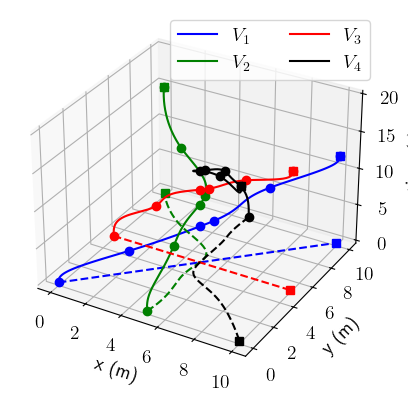

In [2]:
import numpy as np
import minsnap_trajectories as ms
import matplotlib.pyplot as plt
from plan_poly import plan_poly_traj

fig = plt.figure()
ax = plt.axes(projection='3d')


## waypoint = [t , p_x , p_y]
aircraft_1_wp = np.array([[0.0, 0.0, 0.0],
                          [3.0, 2.5, 2.5],
                          [5.0, 5.0, 5.0],
                          [5.5, 5.5, 5.5],
                          [9.0, 7.5, 7.5],
                          [12.0, 10.0, 10.0]
                          ])

aircraft_2_wp = np.array([[0.0, 5.0, 0.0],
                          [5.5, 5.0, 2.5],
                          [8.0, 5.0, 5.0],
                          [8.5, 5.0, 5.5],
                          [11.0, 2.5, 7.5],
                          [15.0, 0.0, 10.0]
                          ])
aircraft_3_wp = np.array([[0.0, 0.0, 5.0],
                          [6.0, 2.5, 5.0],
                          [10.0, 5.0, 5.0],
                          [10.5, 5.5, 5.0],
                          [13.0, 7.5, 5.0],
                          [16.0, 10.0, 5.0]
                          ])

aircraft_4_wp = np.array([[0.0, 5.0, 10.0],
                          [9.5, 5.0, 7.5],
                          [12.0, 5.0, 5.5],
                          [12.5, 5.0, 5.0],
                          [16.5, 7.5, 2.5],
                          [20.0, 10.0, 0.0]
                          ])

wps = np.array([aircraft_1_wp, aircraft_2_wp, aircraft_3_wp, aircraft_4_wp])
lbls= ['$V_1$', '$V_2$', '$V_3$', '$V_4$']
colors = ['b', 'g', 'r', 'k']
wp_start = ['o', 'o', 'o', 'o']
wp_goal = ['s', 's', 's', 's']

n_agents = 4
trajs = []
for i in range(n_agents):
    boundary_cdn = []
    for j in range(wps[i].shape[0]):
        boundary_cdn += [
            ms.Waypoint(
                time=wps[i][j,0],
                position=wps[i][j,1:3],
            )
        ]
 
    t, pos, vel = plan_poly_traj(boundary_cdn, wps[i][-1,0], 0.1)
    ax.plot3D(pos[:, 0], pos[:, 1], t, color = colors[i], label=lbls[i])
    ax.plot(pos[:, 0], pos[:, 1], '--', color = colors[i])
    
    position_waypoints = np.array([it.position for it in boundary_cdn])
    time_waypoints = np.array([it.time for it in boundary_cdn])
    ax.plot(
        position_waypoints[:, 0],
        position_waypoints[:, 1],
        time_waypoints,
        wp_start[i],
        color = colors[i]
    )
    ax.plot(
        position_waypoints[-1, 0],
        position_waypoints[-1, 1],
        wp_goal[i],
        color = colors[i]
    )
    ax.plot(
        position_waypoints[-1, 0],
        position_waypoints[-1, 1],
        time_waypoints[-1],
        wp_goal[i],
        color = colors[i]
    )
    traj = {}
    traj['x'] = pos[:, 0]
    traj['y'] = pos[:, 1]
    traj['theta'] = np.arctan2(
                vel[:, 1], vel[:, 0]
            )
    traj['v'] = np.linalg.norm(vel[:,:], axis = 1)

    trajs.append(traj)

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("time (s)")
ax.legend(loc="upper right", ncol = 2)
plt.grid()
plt.show()

Cell 1: pop-up obstacle:   0%|          | 0/200 [00:00<?, ?it/s]


  ⚡ Obstacle injected at t=0  pos=(5.0, 5.0)


Cell 1: pop-up obstacle: 100%|██████████| 200/200 [02:48<00:00,  1.18it/s]



── Cell 1 metrics ──

════════════════════════════════════════════════════
  Solve latency (ms)
    V1: mean=32.7  p95=41.9  max=56.1
    V2: mean=32.5  p95=41.7  max=59.3
    V3: mean=31.8  p95=41.6  max=52.0
    V4: mean=34.2  p95=42.6  max=95.0
  Min separation  : 0.617 m
  Mean separation : 1.610 m
  Violations (<1.0m): 66
  Infeasible solves: 0
  Path lengths    : [np.float64(16.04), np.float64(12.58), np.float64(10.61), np.float64(12.47)]
════════════════════════════════════════════════════



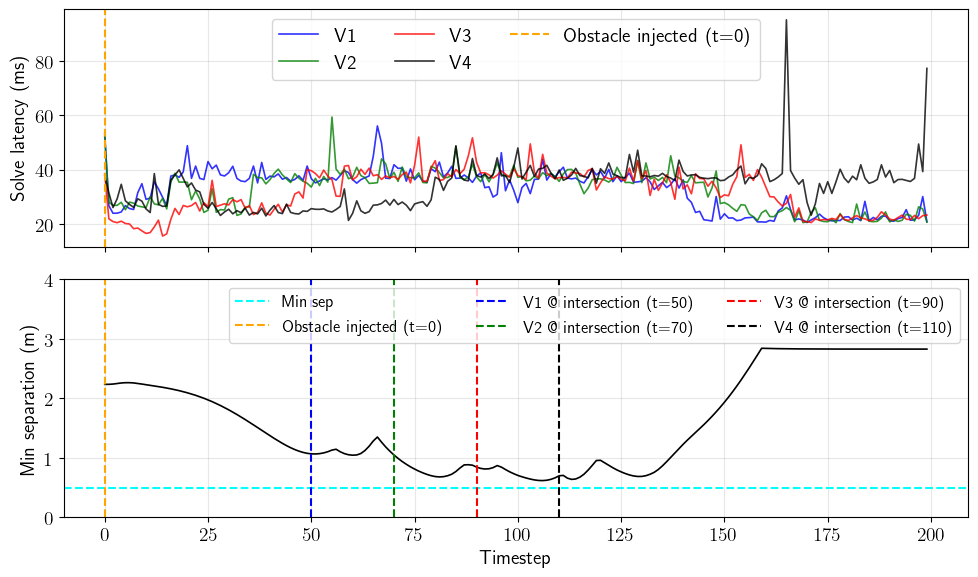

In [28]:
# ─── Cell 1: Pop-up static obstacle ──────────────────────────────────────────
# A new obstacle suddenly appears at INJECT_T while all agents are running.
# Measures: replan latency spike, separation change, infeasibility count.

INJECT_T     = 0          # timestep at which obstacle pops up
V1_T        = 50          # V1 reaches goal at t=30s
V2_T        = 70          # V2 reaches goal at t=35s
V3_T        = 90          # V3 reaches goal at t=40s
V4_T        = 110         # V4 reaches goal at t=45s
NEW_OBS_POS  = (5.0, 5.0)  # location of the new obstacle (x, y)
NEW_OBS_DIAM = 0.5
max_iter     = 200

Q_x = 10
Q_y = 10
Q_theta = 5
Q_v = 5
R_a = 0.01
R_delta = 0.01

dt = 0.1
N = 30

L = 1
a_lim = [-0.5, 0.5]
delta_lim = [-casadi.pi/6, casadi.pi/6]
Q = [Q_x, Q_y, Q_theta, Q_v]
R = [R_a, R_delta]

n_agents = 4


agents_init_state = np.array([[0.0, 0.0, np.pi/4, 0.0], [5.0, 0.0, np.pi/2, 0.0], [0.0, 5.0, 0, 0.0], [5.0, 10.0, -np.pi/2, 0.0]])
agents_goal_state = np.array([[10.0, 10.0, np.pi/4, 0.0], [0.0, 10.0, -3*np.pi/4, 0.0], [10.0, 5.0, 0, 0.0], [10.0, 10.0, -np.pi/4, 0.0]])

ref_state_list = [np.array([
    trajs[j]['x'][:-1].tolist(),
    trajs[j]['y'][:-1].tolist(), 
    trajs[j]['theta'][:-1].tolist(),
    trajs[j]['v'][:-1].tolist()]).T
    for j in range(n_agents)]


# ── Re-initialise agents cleanly ──────────────────────────────────────────────

state_0_list = [casadi.DM([
    agents_init_state[i][0], 
    agents_init_state[i][1], 
    agents_init_state[i][2],
    agents_init_state[i][3]]) for i in range(n_agents)]

agents_c1 = [MPC_CBF_Bicycle(
    agents_init_state[i], n_agents-1, dt, N,
    a_lim, delta_lim, L, Q, R,
    obstacles=[(4, 2), (8, 9)], obs_diam=NEW_OBS_DIAM, alpha=0.15, cbf_const=True)
    for i in range(n_agents)]
X0_list_c1      = [casadi.repmat(state_0_list[i], 1, N + 1) for i in range(n_agents)]
u0_list_c1   = [casadi.DM.zeros((agents_c1[i].n_controls, N)) for i in range(n_agents)]
t0_list_c1   = [0] * n_agents
obs_list_c1  = []      # baseline obstacles (no popup yet)
logger_c1    = MetricLogger(n_agents)


agents_state_list_c1   = [dm_to_array(casadi.repmat(casadi.DM(agents_init_state[i]), 1, N+1))
                           for i in range(n_agents)]
agents_control_list_c1 = [dm_to_array(casadi.DM.zeros((agents_c1[i].n_controls, N)))
                           for i in range(n_agents)]

prev_states_c1 = agents_init_state.copy()

for t in tqdm(range(max_iter), desc="Cell 1: pop-up obstacle"):
    agent_states = np.array([agents_c1[i].states for i in range(n_agents)])

    # ── Inject new obstacle at INJECT_T ──────────────────────────────────────
    if t < INJECT_T:
        current_obs = [(4, 2), (8, 8)]
    else:
        if t == INJECT_T:
            print(f"\n  ⚡ Obstacle injected at t={t}  pos={NEW_OBS_POS}")
        current_obs = [(4, 2), (8, 8), NEW_OBS_POS]
        agents_c1 = [MPC_CBF_Bicycle(
        agent_states[i], n_agents-1, dt, N,
        a_lim, delta_lim, L, Q, R,
        obstacles=current_obs, obs_diam=NEW_OBS_DIAM, alpha=0.14, cbf_const=True)
        for i in range(n_agents)]
    obs_list_c1.append(current_obs)
    logger_c1.log_separation(t, agent_states, current_obs)

    u_list_c1   = [None] * n_agents
    X_pred_c1   = [None] * n_agents

    for j in range(n_agents):
        neighbors = np.array([agent_states[k] for k in range(n_agents) if k != j])
        u_list_c1[j], X_pred_c1[j], ok = safe_solve(
            agents_c1[j], X0_list_c1[j], u0_list_c1[j],
            ref_state_list[j], t, neighbors, current_obs, logger_c1, j)
        if not ok:
            logger_c1.log_replan(t, j, 'infeasible_after_popup')

    for j in range(n_agents):
        agents_state_list_c1[j]   = np.dstack((agents_state_list_c1[j],
                                                dm_to_array(X_pred_c1[j])))
        agents_control_list_c1[j] = np.dstack((agents_control_list_c1[j],
                                                dm_to_array(u_list_c1[j])))
        
        logger_c1.log_path(j, prev_states_c1[j], agent_states[j])
        prev_states_c1[j] = agent_states[j].copy()
        t0_list_c1[j], X0_list_c1[j], u0_list_c1[j] = agents_c1[j].shift_timestep(
            dt, t0_list_c1[j], X_pred_c1[j], u_list_c1[j])

print("\n── Cell 1 metrics ──")
results_c1 = logger_c1.summary(T=INJECT_T)
with open(f'autotaxiing_case1_{INJECT_T}s.txt', 'w') as f:
    f.write("Cell 1 Metrics Summary:\n")
    for key, value in results_c1.items():
        f.write(f"{key}: {value}\n")

# ── Solve latency plot (highlight injection moment) ───────────────────────────
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

colors = ['b','g','r','k']
for j in range(n_agents):
    axes[0].plot(logger_c1.solve_times[j], color=colors[j],
                 alpha=0.8, lw=1.2, label=f'V{j+1}')
axes[0].axvline(INJECT_T, color='orange', linestyle='--', lw=1.5, label=f'Obstacle injected (t={INJECT_T})')
axes[0].set_ylabel("Solve latency (ms)"); axes[0].legend(ncol=3, fontsize=14); axes[0].grid(alpha=0.3)

sep_t, sep_v = zip(*logger_c1.separations)
axes[1].plot(sep_t, sep_v, 'k-', lw=1.2)
axes[1].axhline(0.5, color='cyan', linestyle='--', lw=1.5, label='Min sep')
axes[1].axvline(INJECT_T, color='orange', linestyle='--', lw=1.5, label=f'Obstacle injected (t={INJECT_T})')
axes[1].axvline(V1_T, color='blue', linestyle='--', lw=1.5, label=f'V1 @ intersection (t={V1_T})')
axes[1].axvline(V2_T, color='green', linestyle='--', lw=1.5, label=f'V2 @ intersection (t={V2_T})')
axes[1].axvline(V3_T, color='red', linestyle='--', lw=1.5, label=f'V3 @ intersection (t={V3_T})')
axes[1].axvline(V4_T, color='black', linestyle='--', lw=1.5, label=f'V4 @ intersection (t={V4_T})')

axes[1].set_xlabel("Timestep"); axes[1].set_ylabel("Min separation (m)")
axes[1].legend(ncols=3,fontsize=12); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 4)
plt.tight_layout()
plt.savefig(f"autotaxiing_case1_{INJECT_T}s.png", dpi=300)
plt.show()

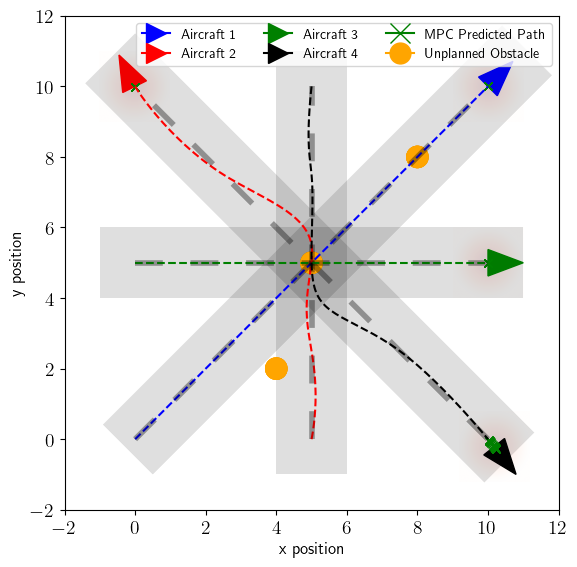

In [29]:
%load_ext autoreload
%autoreload 2
anim_params = {
    'n_agents': n_agents,
    'ref_state_list': ref_state_list,
    'agents_init_state':agents_init_state,
    'agents_state_list':agents_state_list_c1,
    'agents_control_list':agents_control_list_c1,
    'num_frames':max_iter,
    'max_iter':max_iter,
    'pred_horizon':N,
    'save': False,
    'obs_list': obs_list_c1,

}
sim = animate(anim_params)
from IPython.display import HTML
HTML(sim.to_html5_video())

In [21]:
# ─── Cell 2: Obstacle speed variation ────────────────────────────────────────
# Runs three sub-trials where obstacle drift speed is varied.
# Compares: violations, latency, and path overhead across speeds.

SPEED_CONFIGS = {
    'slow':   (0.0002, 0.0002),   # (x_rate, y_rate) per timestep
    'medium': (0.004,  0.004),    # your original config
    'fast':   (0.01,   0.01),
}
max_iter = 150
results_c2 = {}

for speed_label, (rx, ry) in SPEED_CONFIGS.items():
    state_0_list = [casadi.DM([
    agents_init_state[i][0], 
    agents_init_state[i][1], 
    agents_init_state[i][2],
    agents_init_state[i][3]]) for i in range(n_agents)]

    agents_c2 = [MPC_CBF_Bicycle(
        agents_init_state[i], n_agents-1, dt, N,
        a_lim, delta_lim, L, Q, R,
        obstacles=[(4, 4),(8, 9)], obs_diam=0.4, alpha=0.15, cbf_const=True)
        for i in range(n_agents)]

    X0_c2   = [casadi.repmat(state_0_list[i], 1, N + 1) for i in range(n_agents)]
    u0_c2   = [casadi.DM.zeros((agents_c2[i].n_controls, N)) for i in range(n_agents)]
    t0_c2   = [0]*n_agents
    logger  = MetricLogger(n_agents)
    prev_st = agents_init_state.copy()

    for t in tqdm(range(max_iter), desc=f"Cell 2 [{speed_label}]", leave=False):
        agent_states = np.array([agents_c2[i].states for i in range(n_agents)])
        current_obs  = [(4 + t*rx, 4 + t*ry), (8 + t*rx*4, 9)]
        logger.log_separation(t, agent_states, current_obs)

        u_c2, X_c2 = [None]*n_agents, [None]*n_agents
        for j in range(n_agents):
            neighbors = np.array([agent_states[k] for k in range(n_agents) if k!=j])
            u_c2[j], X_c2[j], _ = safe_solve(
                agents_c2[j], X0_c2[j], u0_c2[j],
                ref_state_list[j], t, neighbors, current_obs, logger, j)
        for j in range(n_agents):
            logger.log_path(j, prev_st[j], agent_states[j])
            prev_st[j] = agent_states[j].copy()
            t0_c2[j], X0_c2[j], u0_c2[j] = agents_c2[j].shift_timestep(
                dt, t0_c2[j], X_c2[j], u_c2[j])

    print(f"\n── Cell 2 [{speed_label}] ──")
    results_c2[speed_label] = logger.summary()
    with open(f'autotaxiing_case2_{speed_label}.txt', 'w') as f:
        f.write("Cell 2 Metrics Summary:\n")
        for key, value in results_c2[speed_label].items():
            f.write(f"{key}: {value}\n")



── Cell 2 [slow] ──

════════════════════════════════════════════════════
  Solve latency (ms)
    V1: mean=17.7  p95=19.5  max=25.0
    V2: mean=17.6  p95=19.2  max=24.7
    V3: mean=16.0  p95=18.8  max=25.0
    V4: mean=16.4  p95=19.2  max=25.7
  Min separation  : 0.811 m
  Mean separation : 1.802 m
  Violations (<1.0m): 10
  Infeasible solves: 0
  Path lengths    : [np.float64(15.35), np.float64(12.68), np.float64(9.91), np.float64(6.79)]
════════════════════════════════════════════════════




── Cell 2 [medium] ──

════════════════════════════════════════════════════
  Solve latency (ms)
    V1: mean=17.6  p95=19.3  max=22.7
    V2: mean=17.8  p95=19.1  max=25.7
    V3: mean=16.2  p95=19.0  max=23.1
    V4: mean=16.3  p95=18.9  max=25.4
  Min separation  : 0.677 m
  Mean separation : 1.670 m
  Violations (<1.0m): 37
  Infeasible solves: 0
  Path lengths    : [np.float64(15.4), np.float64(12.66), np.float64(9.91), np.float64(6.82)]
════════════════════════════════════════════════════




── Cell 2 [fast] ──

════════════════════════════════════════════════════
  Solve latency (ms)
    V1: mean=17.1  p95=19.3  max=23.3
    V2: mean=17.6  p95=19.1  max=26.3
    V3: mean=16.2  p95=18.5  max=25.5
    V4: mean=16.2  p95=19.1  max=25.2
  Min separation  : 0.545 m
  Mean separation : 1.717 m
  Violations (<1.0m): 59
  Infeasible solves: 0
  Path lengths    : [np.float64(15.38), np.float64(12.82), np.float64(9.89), np.float64(6.6)]
════════════════════════════════════════════════════



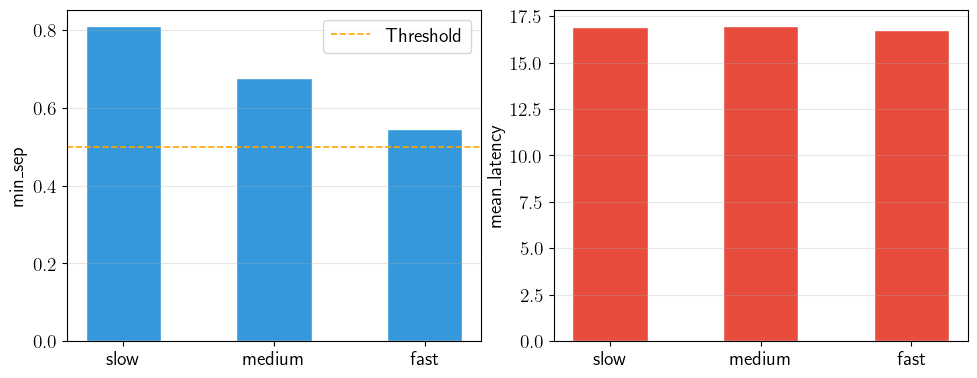

In [22]:
# ── Comparison bar chart ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

labels = list(SPEED_CONFIGS.keys())
metrics = ['min_sep', 'mean_latency']
bar_colors = ['#3498db','#e74c3c']

for ax, metric, col in zip(axes, metrics, bar_colors):
    vals = [results_c2[s][metric] for s in labels]
    ax.bar(labels, vals, color=col, edgecolor='white', width=0.5)
    ax.set_ylabel(metric); ax.grid(axis='y', alpha=0.3)
    if metric == 'min_sep':
        ax.axhline(0.5, color='orange', linestyle='--', lw=1.2, label='Threshold')
        ax.legend(fontsize=14)

plt.tight_layout()
plt.savefig(f"autotaxiing_case2.png", dpi=300)
plt.show()


Cell 3: agent speed surge:  32%|███▏      | 64/200 [00:04<00:09, 15.08it/s]


  ⚡ V2 speed surge at t=61:  Δv = +1.0 m/s


Cell 3: agent speed surge: 100%|██████████| 200/200 [00:12<00:00, 15.40it/s]



── Cell 3 metrics ──

════════════════════════════════════════════════════
  Solve latency (ms)
    V1: mean=16.1  p95=19.7  max=24.6
    V2: mean=15.9  p95=19.1  max=26.5
    V3: mean=15.1  p95=18.9  max=33.2
    V4: mean=16.7  p95=19.6  max=27.5
  Min separation  : 0.823 m
  Mean separation : 1.486 m
  Violations (<1.0m): 31
  Infeasible solves: 0
  Path lengths    : [np.float64(15.23), np.float64(13.14), np.float64(10.35), np.float64(12.75)]
════════════════════════════════════════════════════



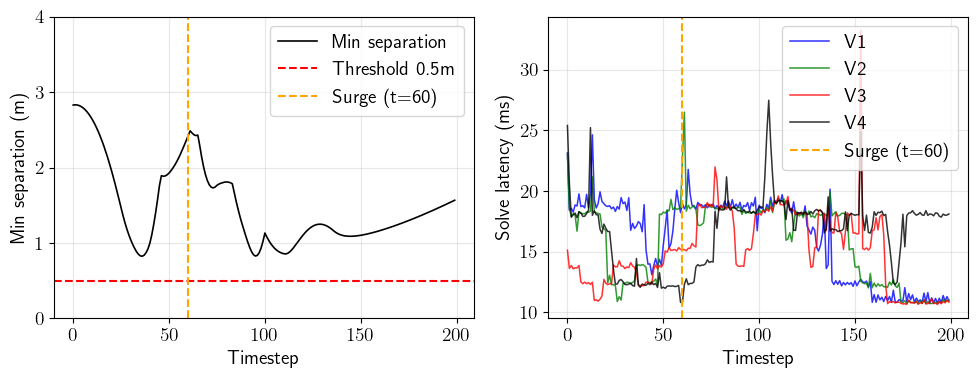

In [27]:
# ─── Cell 3: Sudden agent speed change ────────────────────────────────────────
# At SURGE_T, we inject a velocity disturbance into V2's state directly.
# This simulates an aircraft that deviates from its cleared speed profile.
# We measure the CBF response: does constraint enforcement hold?

SURGE_T     = 60           # timestep of speed disturbance
SURGE_DV    = 1.0         # sudden velocity increase (m/s added to V2's state)
max_iter    = 200

agents_c3   = [MPC_CBF_Bicycle(
    agents_init_state[i], n_agents-1, dt, N,
    a_lim, delta_lim, L, Q, R,
    obstacles=[(8,2),(8,9)], obs_diam=0.4, alpha=0.15, cbf_const=True)
    for i in range(n_agents)]
state_0_list = [casadi.DM([
    agents_init_state[i][0], 
    agents_init_state[i][1], 
    agents_init_state[i][2],
    agents_init_state[i][3]]) for i in range(n_agents)]
X0_c3   = [casadi.repmat(state_0_list[i], 1, N + 1) for i in range(n_agents)]
u0_c3   = [casadi.DM.zeros((agents_c3[i].n_controls, N)) for i in range(n_agents)]
t0_c3   = [0]*n_agents
logger_c3 = MetricLogger(n_agents)
prev_st   = agents_init_state.copy()
surged    = False
obs_list_c3 = []
agents_state_list_c3   = [dm_to_array(casadi.repmat(casadi.DM(agents_init_state[i]), 1, N+1))
                           for i in range(n_agents)]
agents_control_list_c3 = [dm_to_array(casadi.DM.zeros((agents_c3[i].n_controls, N)))
                           for i in range(n_agents)]

for t in tqdm(range(max_iter), desc="Cell 3: agent speed surge"):
    agent_states = np.array([agents_c3[i].states for i in range(n_agents)])

   

    current_obs = [(2 + t*0.004, 2 + t*0.00016), (8+t*0.016, 9)]
    obs_list_c3.append(current_obs)
    logger_c3.log_separation(t, agent_states, current_obs)

    u_c3, X_c3 = [None]*n_agents, [None]*n_agents
    for j in range(n_agents):
        neighbors = np.array([agent_states[k] for k in range(n_agents) if k!=j])
        u_c3[j], X_c3[j], ok = safe_solve(
            agents_c3[j], X0_c3[j], u0_c3[j],
            ref_state_list[j], t, neighbors, current_obs, logger_c3, j)
    # ── Inject speed disturbance into V2 at SURGE_T ──────────────────────────
    if t > SURGE_T and not surged:
        current_v2 = X0_c3[1][3,0]
        #print(current_v2)
        current_v2 = current_v2 + SURGE_DV #min(current_v2 + SURGE_DV, a_lim[1]*10)  # cap at reasonable max
        X_c3[1][3,:] = current_v2          # force state update
        logger_c3.log_replan(t, 1, f'speed_surge +{SURGE_DV}m/s')
        surged = True
        print(f"\n  ⚡ V2 speed surge at t={t}:  Δv = +{SURGE_DV} m/s")
    for j in range(n_agents):
        agents_state_list_c3[j]   = np.dstack((agents_state_list_c3[j],
                                                dm_to_array(X_c3[j])))
        agents_control_list_c3[j] = np.dstack((agents_control_list_c3[j],
                                                dm_to_array(u_c3[j])))
        logger_c3.log_path(j, prev_st[j], agent_states[j])
        prev_st[j] = agent_states[j].copy()
        t0_c3[j], X0_c3[j], u0_c3[j] = agents_c3[j].shift_timestep(
            dt, t0_c3[j], X_c3[j], u_c3[j])

print("\n── Cell 3 metrics ──")
results_c3 = logger_c3.summary()
with open(f'autotaxiing_case3_{SURGE_DV}.txt', 'w') as f:
    f.write("Cell 3 Metrics Summary:\n")
    for key, value in results_c3.items():
        f.write(f"{key}: {value}\n")

# ── Phase-space plot: V2 velocity over time ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sep_t, sep_v = zip(*logger_c3.separations)
axes[0].plot(sep_t, sep_v, 'k-', lw=1.2, label='Min separation')
axes[0].axhline(0.5, color='red', linestyle='--', lw=1.5, label='Threshold 0.5m')
axes[0].axvline(SURGE_T, color='orange', linestyle='--', lw=1.5, label=f'Surge (t={SURGE_T})')
axes[0].set_xlabel("Timestep"); axes[0].set_ylabel("Min separation (m)")
axes[0].legend(fontsize=14); axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 4)

for j in range(n_agents):
    lat = logger_c3.solve_times[j]
    axes[1].plot(lat, color=colors[j], alpha=0.8, lw=1.1, label=f'V{j+1}')
axes[1].axvline(SURGE_T, color='orange', linestyle='--', lw=1.5, label=f'Surge (t={SURGE_T})')
axes[1].set_xlabel("Timestep"); axes[1].set_ylabel("Solve latency (ms)")
axes[1].legend(fontsize=14); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"autotaxiing_case3_{SURGE_DV}.png", dpi=300)
plt.show()

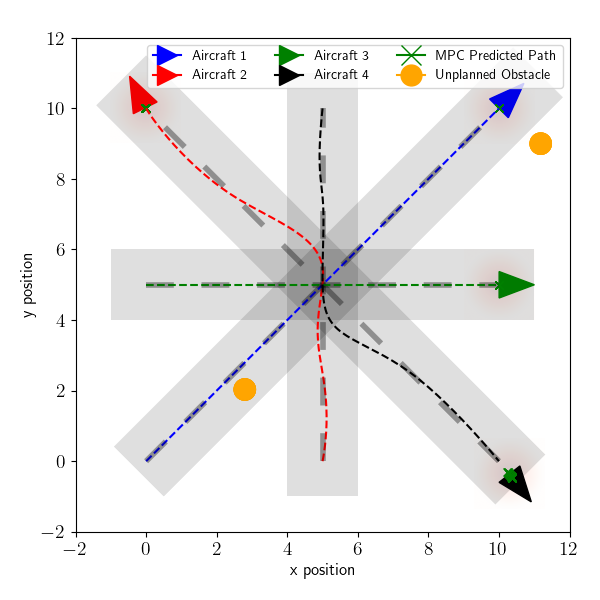

In [82]:
anim_params = {
    'n_agents': n_agents,
    'ref_state_list': ref_state_list,
    'agents_init_state':agents_init_state,
    'agents_state_list':agents_state_list_c3,
    'agents_control_list':agents_control_list_c3,
    'num_frames':max_iter,
    'max_iter':max_iter,
    'pred_horizon':N,
    'save': False,
    'obs_list': obs_list_c3,

}
sim = animate(anim_params)
from IPython.display import HTML
HTML(sim.to_html5_video())

Cell 4: cascading:  27%|██▋       | 40/150 [00:02<00:06, 16.65it/s]


  ⚡ t=40: obstacle injected at (5.0, 5.0)


Cell 4: cascading:  41%|████▏     | 62/150 [00:04<00:06, 12.84it/s]


  ⚡ t=60: V2 speed surge +0.8 m/s


Cell 4: cascading:  61%|██████▏   | 92/150 [00:07<00:04, 11.94it/s]


  ⚡ t=90: V3 heading shift +22.5°


Cell 4: cascading: 100%|██████████| 150/150 [00:11<00:00, 12.73it/s]



── Cell 4 metrics ──

════════════════════════════════════════════════════
  Solve latency (ms)
    V1: mean=19.9  p95=23.7  max=28.4
    V2: mean=19.0  p95=21.7  max=29.0
    V3: mean=18.0  p95=21.1  max=24.5
    V4: mean=17.8  p95=21.1  max=28.5
  Min separation  : 0.677 m
  Mean separation : 1.289 m
  Violations (<1.0m): 49
  Infeasible solves: 0
  Path lengths    : [np.float64(15.88), np.float64(12.67), np.float64(10.08), np.float64(6.84)]
════════════════════════════════════════════════════



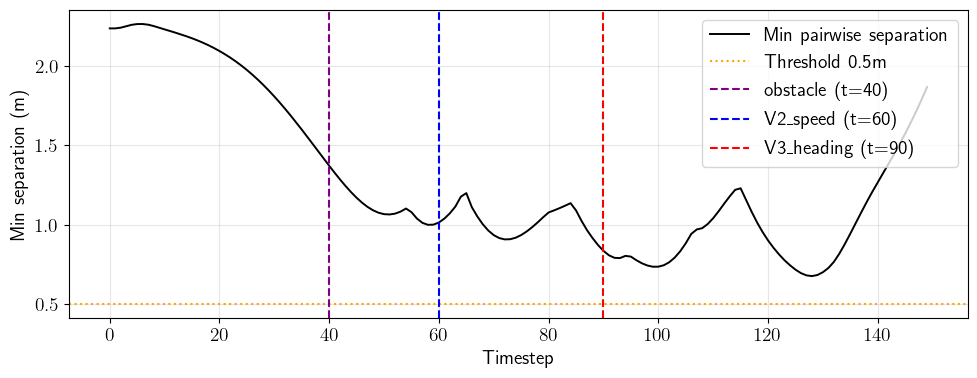

In [57]:
# ─── Cell 4: Cascading disturbances ──────────────────────────────────────────
# Three events fire in sequence:
#   t=30  → new static obstacle appears at (5, 5)
#   t=60  → V2 gets a sudden speed surge
#   t=90  → V3 gets a heading disturbance (theta offset)

EVENTS = {
    40:  ('obstacle',  None),
    60:  ('speed',     1),     # agent index of V2
    90:  ('heading',   2),     # agent index of V3
}
POPUP_OBS   = (5.0, 5.0)
SPEED_BUMP  = 0.8              # m/s added to V2
THETA_BUMP  = np.pi / 8        # rad added to V3's heading
max_iter    = 150

agents_c4 = [MPC_CBF_Bicycle(
    agents_init_state[i], n_agents-1, dt, N,
    a_lim, delta_lim, L, Q, R,
    obstacles=[(4,2),(8,8)], obs_diam=0.4, alpha=0.15, cbf_const=True)
    for i in range(n_agents)]
state_0_list = [casadi.DM([
    agents_init_state[i][0], 
    agents_init_state[i][1], 
    agents_init_state[i][2],
    agents_init_state[i][3]]) for i in range(n_agents)]
X0_c4   = [casadi.repmat(state_0_list[i], 1, N + 1) for i in range(n_agents)]
u0_c4  = [casadi.DM.zeros((agents_c4[i].n_controls, N)) for i in range(n_agents)]
t0_c4  = [0]*n_agents
logger_c4 = MetricLogger(n_agents)
prev_st   = agents_init_state.copy()
event_log = []
current_obs = [(4, 2), (8, 8)]
agents_state_list_c4   = [dm_to_array(casadi.repmat(casadi.DM(agents_init_state[i]), 1, N+1))
                           for i in range(n_agents)]
agents_control_list_c4 = [dm_to_array(casadi.DM.zeros((agents_c4[i].n_controls, N)))
                           for i in range(n_agents)]
obs_list_c4 = []


for t in tqdm(range(max_iter), desc="Cell 4: cascading"):
    agent_states = np.array([agents_c4[i].states for i in range(n_agents)])

    
    obs_list_c4.append(current_obs)

    logger_c4.log_separation(t, agent_states, current_obs)

    u_c4, X_c4 = [None]*n_agents, [None]*n_agents
    for j in range(n_agents):
        neighbors = np.array([agent_states[k] for k in range(n_agents) if k!=j])
        u_c4[j], X_c4[j], _ = safe_solve(
            agents_c4[j], X0_c4[j], u0_c4[j],
            ref_state_list[j], t, neighbors, current_obs, logger_c4, j)
    # ── Fire events ───────────────────────────────────────────────────────────
    if t in EVENTS:
        kind, target = EVENTS[t]
        if kind == 'obstacle':
            print(f"\n  ⚡ t={t}: obstacle injected at {POPUP_OBS}")
            event_log.append((t, 'obstacle'))
            current_obs = [(4, 2), (8, 8), POPUP_OBS]
            agents_c4 = [MPC_CBF_Bicycle(
            agent_states[i], n_agents-1, dt, N,
            a_lim, delta_lim, L, Q, R,
            obstacles=current_obs, obs_diam=NEW_OBS_DIAM, alpha=0.15, cbf_const=True)
            for i in range(n_agents)]
        elif kind == 'speed':
            print(f"\n  ⚡ t={t}: V{target+1} speed surge +{SPEED_BUMP} m/s")
            event_log.append((t, f'V{target+1}_speed'))
            current_v = X0_c4[target][3,0]
            current_v = current_v + SPEED_BUMP #min(current_v + SURGE_DV, a_lim[1]*10)  # cap at reasonable max
            X_c4[target][3,:] = current_v          # force state update
            logger_c4.log_replan(t, 1, f'speed_surge +{SPEED_BUMP}m/s')
        elif kind == 'heading':
            current_theta = X0_c4[target][2,0]
            current_theta = current_theta + THETA_BUMP #min(current_theta + THETA_BUMP, a_lim[1]*10)  # cap at reasonable max
            X_c4[target][2,:] = current_theta          # force state update
            logger_c4.log_replan(t, 1, f'heading_shift +{np.degrees(THETA_BUMP):.1f}°')
            print(f"\n  ⚡ t={t}: V{target+1} heading shift +{np.degrees(THETA_BUMP):.1f}°")
            event_log.append((t, f'V{target+1}_heading'))
    for j in range(n_agents):
        agents_state_list_c4[j]   = np.dstack((agents_state_list_c4[j],
                                                dm_to_array(X_c4[j])))
        agents_control_list_c4[j] = np.dstack((agents_control_list_c4[j],
                                                dm_to_array(u_c4[j])))
        logger_c4.log_path(j, prev_st[j], agent_states[j])
        prev_st[j] = agent_states[j].copy()
        t0_c4[j], X0_c4[j], u0_c4[j] = agents_c4[j].shift_timestep(
            dt, t0_c4[j], X_c4[j], u_c4[j])

print("\n── Cell 4 metrics ──")
results_c4 = logger_c4.summary()

# ── Separation timeline with event markers ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
sep_t, sep_v = zip(*logger_c4.separations)
ax.plot(sep_t, sep_v, 'k-', lw=1.4, label='Min pairwise separation')
ax.axhline(0.5, color='orange', linestyle=':', lw=1.5, label='Threshold 0.5m')
event_colors = {'obstacle':'purple','V2_speed':'blue','V3_heading':'red'}
for (te, label) in event_log:
    col = event_colors.get(label, 'gray')
    ax.axvline(te, color=col, linestyle='--', lw=1.5, label=f'{label} (t={te})')
ax.set_xlabel("Timestep"); ax.set_ylabel("Min separation (m)")
ax.legend(fontsize=14, loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"autotaxiing_case4_speed{SPEED_BUMP}_angle{np.degrees(THETA_BUMP):.1f}.png", dpi=300)
plt.show()

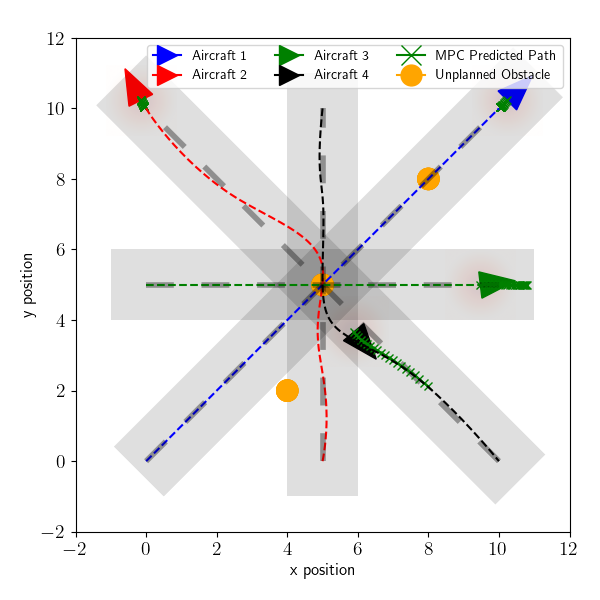

In [84]:
anim_params = {
    'n_agents': n_agents,
    'ref_state_list': ref_state_list,
    'agents_init_state':agents_init_state,
    'agents_state_list':agents_state_list_c4,
    'agents_control_list':agents_control_list_c4,
    'num_frames':max_iter,
    'max_iter':max_iter,
    'pred_horizon':N,
    'save': False,
    'obs_list': obs_list_c4,

}
sim = animate(anim_params)
from IPython.display import HTML
HTML(sim.to_html5_video())

Cell 5: Monte Carlo: 100%|██████████| 50/50 [24:37<00:00, 29.54s/it]   



════════════════════════════════════════════════════
  MC Trials           : 50
  Overall success     : 90.0%
  Mean latency (ms)   : 47.48
  Min sep overall (m) : 0.364
  Total infeasible    : 0
════════════════════════════════════════════════════


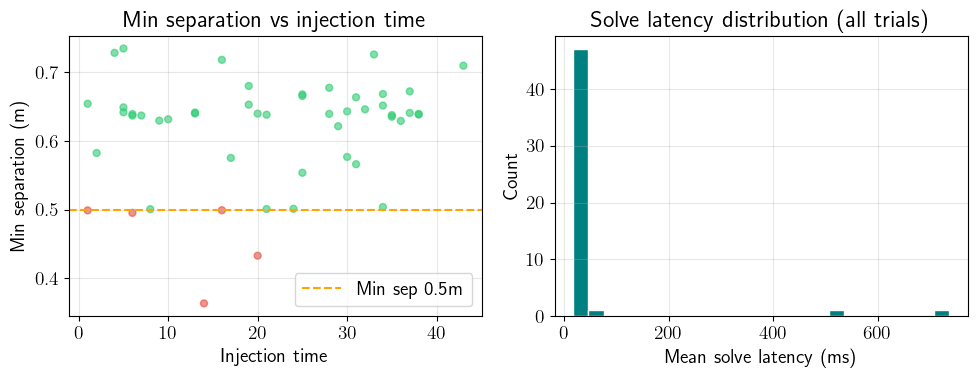

Results saved to mc_results_dynamic_env.csv


In [ ]:
# ─── Cell 5: Monte Carlo sweep ────────────────────────────────────────────────
# N_TRIALS runs with randomised obstacle injection time and position.
# Records success rate, latency, and min separation as functions of
# injection time — produces the key "safe operating envelope" curve.

import pandas as pd

N_TRIALS = 50     # increase to 300+ for final paper results
RNG      = np.random.default_rng(42)
MC_RESULTS = []

for trial in tqdm(range(N_TRIALS), desc="Cell 5: Monte Carlo"):
    t_inj = int(RNG.uniform(0, 45))          # random injection timestep
    ox    = RNG.uniform(4.0, 9.0)              # random obstacle x
    oy    = 5             # random obstacle y

    agents_mc = [MPC_CBF_Bicycle(
        agents_init_state[i], n_agents-1, dt, N,
        a_lim, delta_lim, L, Q, R,
        obstacles=[(8,2),(8,9)], obs_diam=0.4, alpha=0.15, cbf_const=True)
        for i in range(n_agents)]
    state_0_list = [casadi.DM([
    agents_init_state[i][0], 
    agents_init_state[i][1], 
    agents_init_state[i][2],
    agents_init_state[i][3]]) for i in range(n_agents)]
    X0_mc  = [casadi.repmat(state_0_list[i], 1, N + 1) for i in range(n_agents)]
    u0_mc  = [casadi.DM.zeros((agents_mc[i].n_controls, N)) for i in range(n_agents)]
    t0_mc  = [0]*n_agents
    logger = MetricLogger(n_agents)
    current_obs = [(8,2),(8,9)]
    for t in range(150):
        agent_states = np.array([agents_mc[i].states for i in range(n_agents)])
        if t == t_inj:
            current_obs = [(8,2),(8,9), (ox, oy)]
            agents_mc = [MPC_CBF_Bicycle(
            agent_states[i], n_agents-1, dt, N,
            a_lim, delta_lim, L, Q, R,
            obstacles=current_obs, obs_diam=NEW_OBS_DIAM, alpha=0.15, cbf_const=True)
            for i in range(n_agents)]
        logger.log_separation(t, agent_states, current_obs)

        u_mc, X_mc = [None]*n_agents, [None]*n_agents
        for j in range(n_agents):
            neighbors = np.array([agent_states[k] for k in range(n_agents) if k!=j])
            u_mc[j], X_mc[j], _ = safe_solve(
                agents_mc[j], X0_mc[j], u0_mc[j],
                ref_state_list[j], t, neighbors, current_obs, logger, j)
        for j in range(n_agents):
            t0_mc[j], X0_mc[j], u0_mc[j] = agents_mc[j].shift_timestep(
                dt, t0_mc[j], X_mc[j], u_mc[j])

    sep_vals = [s for _, s in logger.separations]
    MC_RESULTS.append({
        'trial':     trial,
        't_inject':  t_inj,
        'obs_x':     ox,
        'obs_y':     oy,
        'min_sep':   min(sep_vals),
        'violations':sum(1 for s in sep_vals if s < 0.5),
        'infeasible':len(logger.infeasible),
        'mean_latency': np.mean([np.mean(v) for v in logger.solve_times.values()]),
        'success':   min(sep_vals) >= 0.5 and len(logger.infeasible) == 0,
    })

df_mc = pd.DataFrame(MC_RESULTS)

# ── Print summary ─────────────────────────────────────────────────────────────
print(f"\n{'═'*52}")
print(f"  MC Trials           : {N_TRIALS}")
print(f"  Overall success     : {df_mc['success'].mean()*100:.1f}%")
print(f"  Mean latency (ms)   : {df_mc['mean_latency'].mean():.2f}")
print(f"  Min sep overall (m) : {df_mc['min_sep'].min():.3f}")
print(f"  Total infeasible    : {df_mc['infeasible'].sum()}")
print(f"{'═'*52}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 1. Min separation scatter coloured by success
c_map = df_mc['success'].map({True: '#2ecc71', False: '#e74c3c'})
axes[0].scatter(df_mc['t_inject'], df_mc['min_sep'], c=c_map, alpha=0.6, s=25)
axes[0].axhline(0.5, color='orange', linestyle='--', lw=1.5, label='Min sep 0.5m')
axes[0].set_xlabel("Injection time"); axes[0].set_ylabel("Min separation (m)")
axes[0].legend(fontsize=14)
axes[0].grid(alpha=0.3)

# 2. Solve latency distribution
axes[1].hist(df_mc['mean_latency'], bins=25, color='teal', edgecolor='white')
axes[1].set_xlabel("Mean solve latency (ms)"); axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# ── Save results for paper ────────────────────────────────────────────────────
df_mc.to_csv('mc_results_dynamic_env.csv', index=False)
print("Results saved to mc_results_dynamic_env.csv")